In [ ]:
import pandas as pd

df = pd.read_csv('/content/student_performance.csv')
display(df.head())

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


Average Math Score by Department
         department  avg_math_score
0  Computer Science            85.6
1        Mechanical            71.0
2       Electronics            71.0
3             Civil            63.4

Student Count by Department
         department  student_count
0             Civil              5
1  Computer Science             13
2       Electronics              6
3        Mechanical              6

Top 8 Students
             name  total_score
0      Ananya Das          371
1     Tanvi Mehta          367
2  Akanksha Yadav          365
3      Arjun Nair          356
4     Divya Singh          356
5  Swati Kulkarni          354
6       Amit Bose          336
7      Suresh Rao          334

Average Attendance by Gender
   gender  avg_attendance
0  Female            88.5
1    Male            80.5


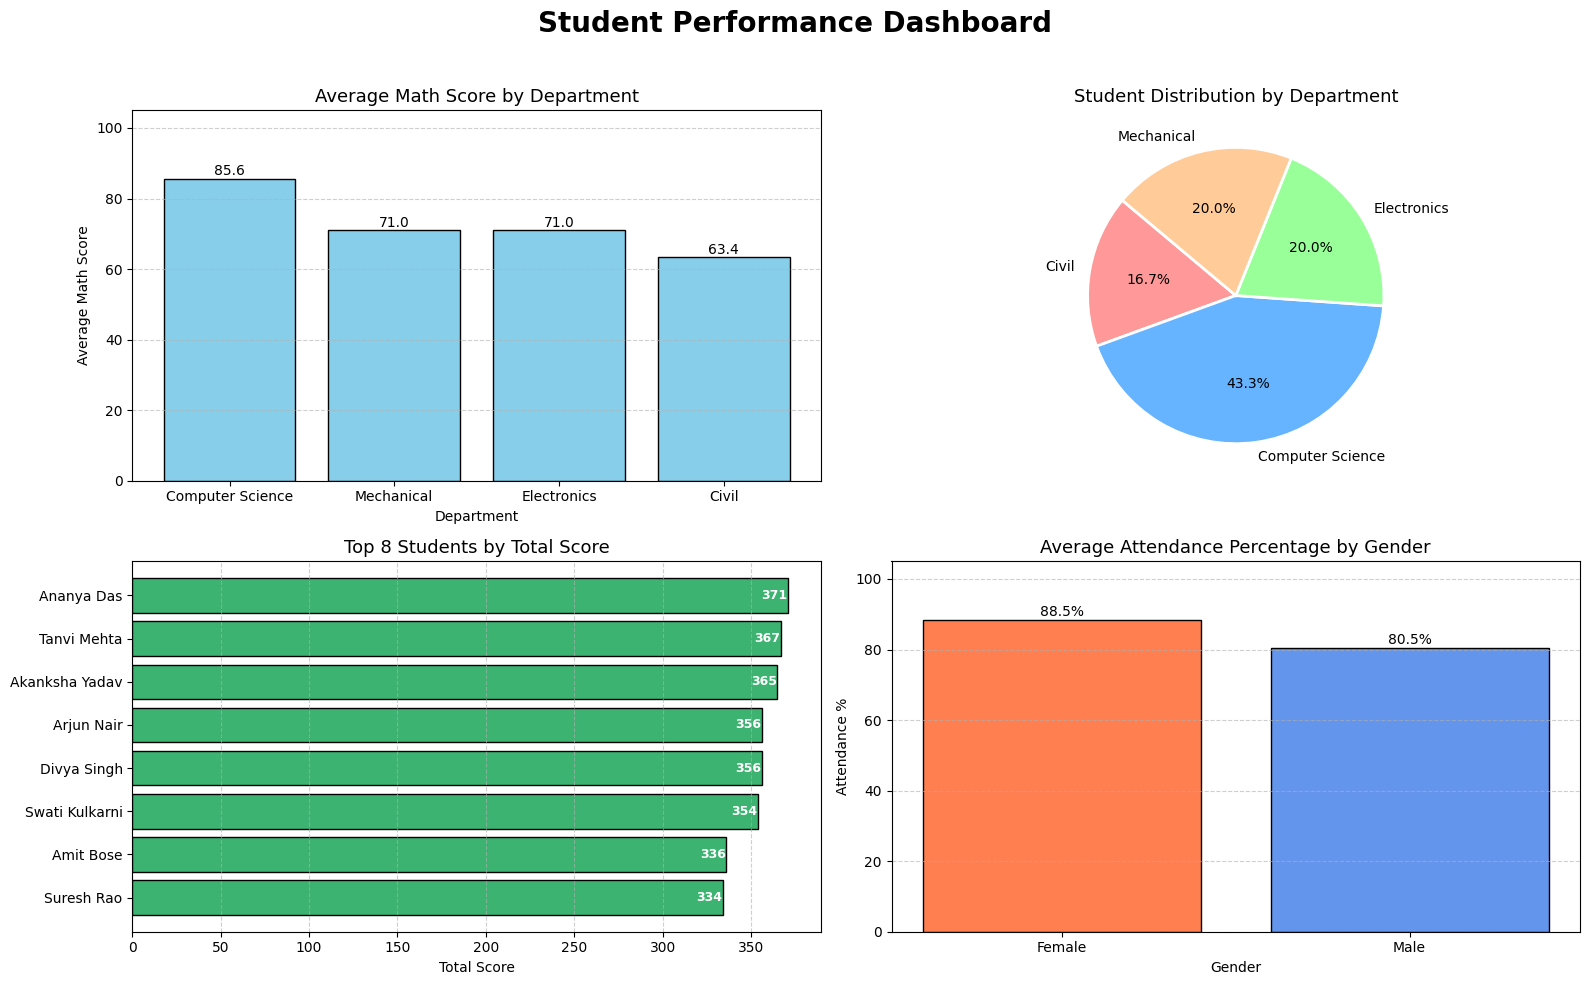


Dashboard saved successfully as 'student_dashboard.png'


In [7]:
# STUDENT PERFORMANCE DASHBOARD


import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import os # Import os module to check for file existence

# Define the file path
file_path = '/content/student_performance.csv'

# Check if the DataFrame CSV file exists
if not os.path.exists(file_path):
    # If the file does not exist, print an error message and raise an exception
    print(f"Error: The required data file '{file_path}' was not found.")
    print("Please ensure 'student_performance.csv' is uploaded to the '/content/' directory.")
    print("You can upload files using the file browser on the left sidebar in Google Colab.")
    raise FileNotFoundError(f"Cannot proceed without '{file_path}'. Please upload the file.")

# Load the DataFrame
df = pd.read_csv(file_path)

# Connect to SQLite Database


conn = sqlite3.connect("students.db")

# Create 'students' table from DataFrame 'df' if it doesn't exist or replace it
df.to_sql('students', conn, if_exists='replace', index=False)

# 1. Average math score for each department

query1 = """
SELECT
    department,
    ROUND(AVG(math_score), 1) AS avg_math_score
FROM students
GROUP BY department
ORDER BY avg_math_score DESC;
"""

avg_math_df = pd.read_sql_query(query1, conn)

print("Average Math Score by Department")
print(avg_math_df)


# 2. Number of students in each department

query2 = """
SELECT
    department,
    COUNT(*) AS student_count
FROM students
GROUP BY department;
"""

dept_count_df = pd.read_sql_query(query2, conn)

print("\nStudent Count by Department")
print(dept_count_df)


# 3. Top 8 students based on total marks

query3 = """
SELECT
    name,
    (math_score + science_score + english_score + programming_score) AS total_score
FROM students
ORDER BY total_score DESC
LIMIT 8;
"""

top_students_df = pd.read_sql_query(query3, conn)

print("\nTop 8 Students")
print(top_students_df)


# 4. Average attendance percentage by gender

query4 = """
SELECT
    gender,
    ROUND(AVG(attendance_percentage), 1) AS avg_attendance
FROM students
GROUP BY gender;
"""

attendance_df = pd.read_sql_query(query4, conn)

print("\nAverage Attendance by Gender")
print(attendance_df)


# CREATE DASHBOARD

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# PANEL 1 - Vertical Bar Chart
# Average Math Score by Department

ax1 = axes[0, 0]

bars1 = ax1.bar(
    avg_math_df["department"],
    avg_math_df["avg_math_score"],
    color="skyblue",
    edgecolor="black"
)

ax1.set_title("Average Math Score by Department", fontsize=13)
ax1.set_xlabel("Department")
ax1.set_ylabel("Average Math Score")
ax1.set_ylim(0, 105)
ax1.grid(axis='y', linestyle='--', alpha=0.6)

# Value labels
for bar in bars1:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height}",
        ha='center',
        fontsize=10
    )


# PANEL 2 - Pie Chart
# Student Count by Department

ax2 = axes[0, 1]

colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0']

ax2.pie(
    dept_count_df["student_count"],
    labels=dept_count_df["department"],
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

ax2.set_title("Student Distribution by Department", fontsize=13)


# PANEL 3 - Horizontal Bar Chart
# Top 8 Students

ax3 = axes[1, 0]

# Reverse order so highest scorer appears at top
top_students_plot = top_students_df.iloc[::-1]

bars3 = ax3.barh(
    top_students_plot["name"],
    top_students_plot["total_score"],
    color="mediumseagreen",
    edgecolor="black"
)

ax3.set_title("Top 8 Students by Total Score", fontsize=13)
ax3.set_xlabel("Total Score")
ax3.grid(axis='x', linestyle='--', alpha=0.6)

# Value labels inside bars
for bar in bars3:
    width = bar.get_width()
    ax3.text(
        width - 15,
        bar.get_y() + bar.get_height()/2,
        f"{int(width)}",
        va='center',
        color='white',
        fontsize=9,
        fontweight='bold'
    )


# PANEL 4 - Attendance by Gender

ax4 = axes[1, 1]

bars4 = ax4.bar(
    attendance_df["gender"],
    attendance_df["avg_attendance"],
    color=['#ff7f50', '#6495ed'],
    edgecolor='black'
)

ax4.set_title("Average Attendance Percentage by Gender", fontsize=13)
ax4.set_xlabel("Gender")
ax4.set_ylabel("Attendance %")
ax4.set_ylim(0, 105)
ax4.grid(axis='y', linestyle='--', alpha=0.6)

# Value labels
for bar in bars4:
    height = bar.get_height()
    ax4.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height}%",
        ha='center',
        fontsize=10
    )


# Dashboard Title & Layout

fig.suptitle(
    "Student Performance Dashboard",
    fontsize=20,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

# Save Dashboard

plt.savefig(
    "student_dashboard.png",
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# Confirmation Message

print("\nDashboard saved successfully as 'student_dashboard.png'")

# Close database connection
conn.close()